<a href="https://colab.research.google.com/github/deltorobarba/astrophysics/blob/main/galaxy_collisions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Galaxy collisions**

from book [Introduction to Astronomy and Astrophysics](https://www.physik.uni-hamburg.de/en/hs/group---schmidt/teaching.html#v-33029000)

Module ```galcol``` contains functions for setup, numerical integration, and visualization

In [ ]:
# Module galcol contains functions for setup, numerical integration, and visualization
!git clone https://github.com/deltorobarba/astrophysics.git
%cd astrophysics
import galcol

**Example: Whirlpool-like galaxy by solving differential equations**

This is an example for a nearly edge-on collision. A smaller intruder galaxy moves under an angle of 45° in the $xy$-plane with an impact velocity of about 130 km/s toward a larger, more massive target galaxy. The impact parameter is 6 kpc in $z$-direction.

In [22]:
import astropy.units as unit

# First we define the parameters of the intruder and target galaxies.
galaxies = {
    'intruder' : galcol.parameters(
        # mass in solar masses
        1e10,
        # disk radius in kpc
        5,
        # Cartesian coordinates (x,y,z) of initial position in kpc
        (25,-25,-5),
        # x-, y-, z-components of initial velocity in km/s
        (-75,75,0),
        # normal to galactic plane (disk is in xy-plane)
        (0,0,1),
        # number of rings (each ring will be randomly populated with 1000/5 = 200 stars)
        5,
        # total number of stars
        1000,
        # softening factor defines inner edge of disk (in units of disk radius)
        0.025),
    'target' : galcol.parameters(5e10, 10, (-5,5,1), (15,-15,0), (1,-1,2**0.5), 10, 4000, 0.025),
}

In [23]:
galaxies['intruder']

{'mass': <Quantity 1.e+10 solMass>,
 'radius': <Quantity 5. kpc>,
 'center_pos': <Quantity [ 25., -25.,  -5.] kpc>,
 'center_vel': <Quantity [-75.,  75.,   0.] km / s>,
 'normal': (0, 0, 1),
 'N_rings': 5,
 'N_stars': 1000,
 'softening': 0.025}

In [24]:
galcol.init_disk(galaxies['intruder'])
galcol.init_disk(galaxies['target'])

Plane normal: phi = -45.0°, theta = 45.0°


The dictionaries of the two galaxies now contain additional items, particularly the inititial data of the stars.

In [25]:
galaxies['intruder']

{'mass': <Quantity 1.e+10 solMass>,
 'radius': <Quantity 5. kpc>,
 'center_pos': <Quantity [ 25., -25.,  -5.] kpc>,
 'center_vel': <Quantity [-75.,  75.,   0.] km / s>,
 'normal': (0, 0, 1),
 'N_rings': 5,
 'N_stars': 1000,
 'softening': 0.025,
 'stars_pos': <Quantity [[ 25.68068116,  24.22535095,  25.17464552, ...,  20.93038063,
              21.05504844,  24.03382099],
            [-25.71570512, -25.40179553, -24.19938189, ..., -23.0589439 ,
             -28.06455516, -29.80626009],
            [ -5.        ,  -5.        ,  -5.        , ...,  -5.        ,
              -5.        ,  -5.        ]] kpc>,
 'stars_vel': <Quantity [[  77.74951978,   24.64219456, -298.10552433, ...,
             -117.14350489,  -18.14621056,   16.80949483],
            [ 217.16347849, -123.37910759,  127.01991677, ...,
              -13.10680309,    1.66938669,   56.45064542],
            [   0.        ,    0.        ,    0.        , ...,
                0.        ,    0.        ,    0.        ]] km / s>,


In [26]:
# Solve equations of motion and visualize data
t, data = galcol.evolve_two_disks(galaxies['target'], galaxies['intruder'],
                                  N_steps=10000, N_snapshots=500, time_step=0.05*unit.Myr)

Solving equations of motion for two galaxies (Leapfrog integration)
100 % (stopped at t = 500.0 Myr)


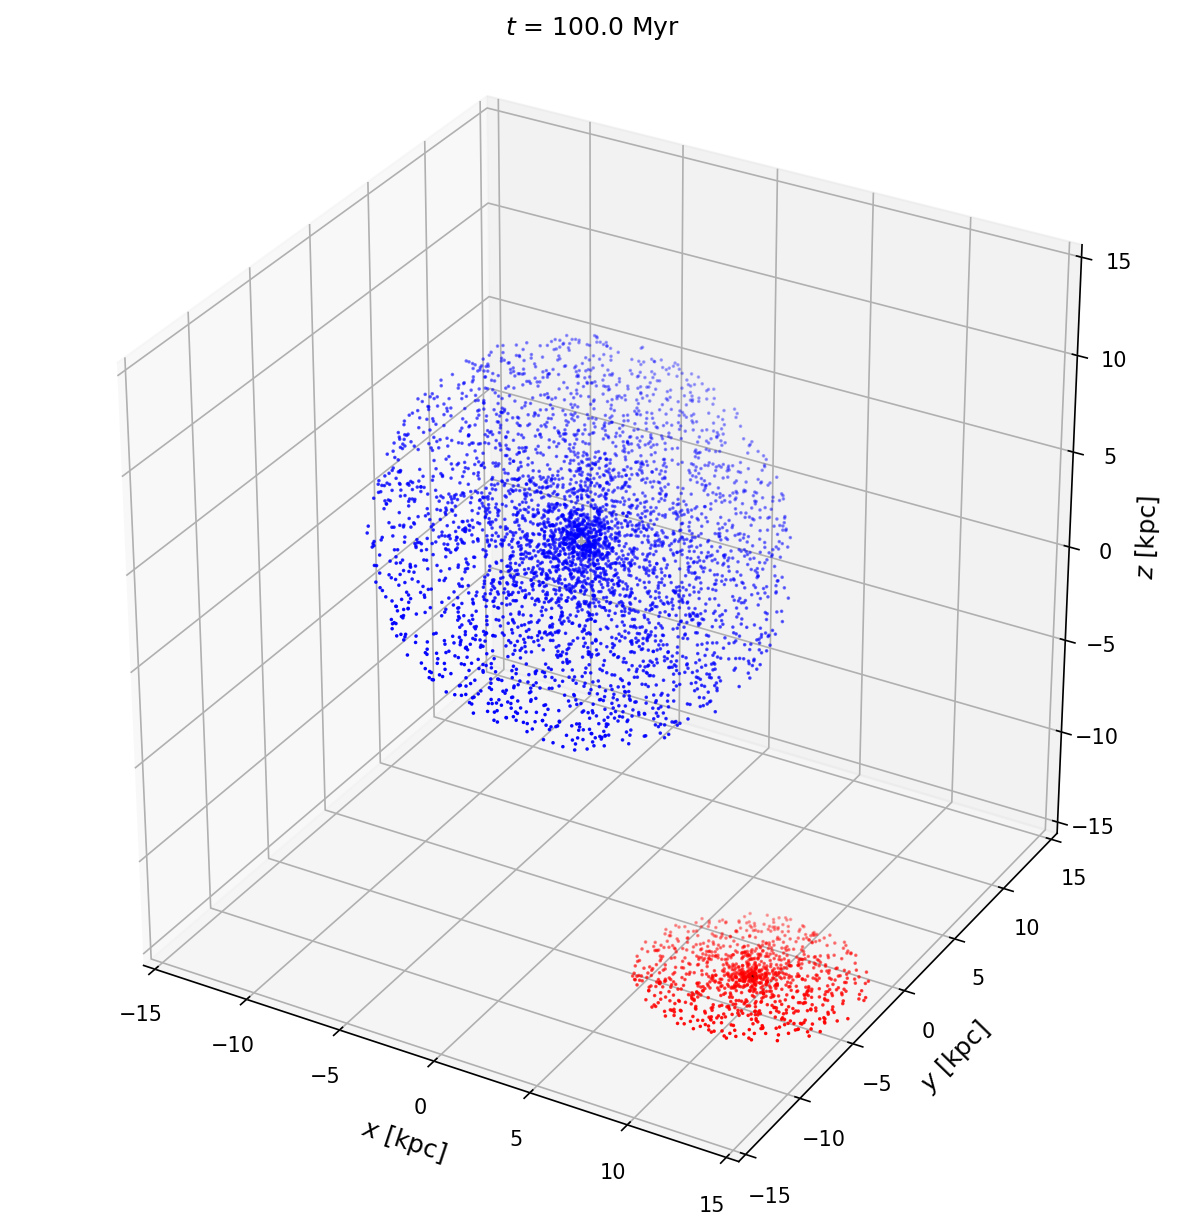

In [27]:
i = 100
galcol.show_two_disks_3d(data[i,:,:], galaxies['target']['N_stars'],
                         [-15,15], [-15,15], [-15,15], t[i], name='two_disks')

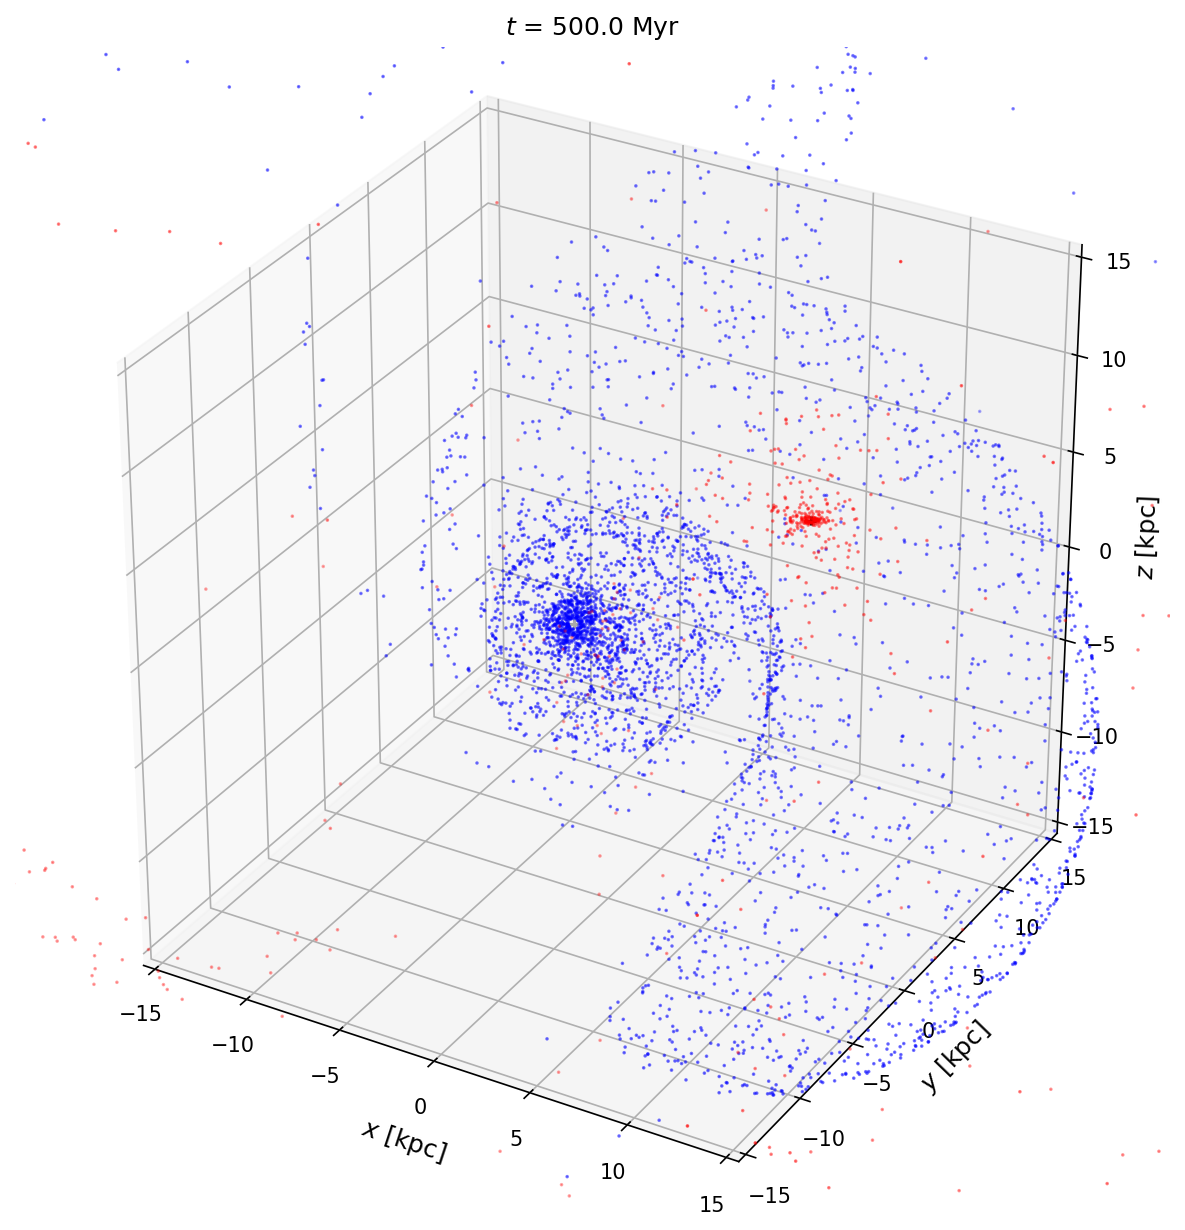

In [28]:
galcol.anim_two_disks_3d(data, galaxies['target']['N_stars'],
                         [-15,15], [-15,15], [-15,15], t, name='two_disks')